# Crop Yield Prediction — Regression Analysis

## Mission

Smallholder farmers and agricultural planners across sub-Saharan Africa need reliable
yield forecasts to plan inputs, insurance, food-security responses, and export
commitments. This project builds a regression model that predicts crop yield (in tonnes
per hectare) from a country, a crop, and three agroclimatic drivers a farmer or
extension officer can access before planting:

- **Area** — country (101 countries, including Rwanda and 30 other African nations)
- **Item** — crop (Potatoes, Maize, Wheat, Rice, Soybeans, Sorghum, Sweet Potatoes, Cassava, Yams, Plantains)
- **Year** — the season being forecast
- **average_rain_fall_mm_per_year** — expected annual rainfall
- **pesticides_tonnes** — annual pesticide use
- **avg_temp** — average annual temperature

The trained model is exported and served through a FastAPI endpoint (Task 2) and a
Flutter mobile app (Task 3) so a user can enter conditions on a phone and receive an
on-the-spot yield estimate.

This is **not** a house-price problem and is not generic — it is a mission-driven
agricultural decision-support use case anchored in African smallholder farming.

## Dataset

**Source:** FAO Crop Yield Prediction Dataset — Kaggle
(`https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset`). Yield and
pesticide records were aggregated from FAO (`https://www.fao.org/faostat/`); rainfall
and temperature from the World Bank Climate Portal.

- **Volume:** 28,242 rows × 8 columns
- **Variety:** 101 countries × 10 crops × 23 years (1990–2013)
- **Missing values:** none

## Notebook contents

1. Setup and data loading
2. Data inspection and target unit conversion
3. Exploratory visualizations and interpretation
4. Feature engineering — drop / keep / encode decisions
5. Standardization
6. Model 1 — Linear Regression optimized with **Stochastic Gradient Descent** (loss curves)
7. Model 2 — Random Forest
8. Model 3 — Decision Tree
9. Model comparison and best-model selection (by lowest test loss)
10. Scatter plots: before vs after fitting the regression line
11. Save the best model + a `predict()` function for the API

## 1. Setup

In [ ]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load the dataset

In [ ]:
def _find_data():
    """Look for the CSV alongside the notebook or up the project tree."""
    for candidate in [
        "yield_df.csv",
        "../yield_df.csv",
        "../../yield_df.csv",
        "../../../yield_df.csv",
    ]:
        if os.path.exists(candidate):
            return candidate
    raise FileNotFoundError("yield_df.csv not found")

df_raw = pd.read_csv(_find_data())
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
print("Dtypes:")
print(df_raw.dtypes)
print("\nMissing values per column:")
print(df_raw.isnull().sum())
print("\nUnique values per column:")
print(df_raw.nunique())

Dtypes:
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing values per column:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Unique values per column:
Unnamed: 0                       28242
Area                               101
Item                                10
Year                                23
hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
pesticides_tonnes                 1673
avg_temp                     

## 3. Preprocessing — clean columns and convert the target unit

**Actions:**

1. Drop `Unnamed: 0` — a leftover row index, not a feature.
2. Convert target from `hg/ha` (hectograms per hectare) to **tonnes per hectare** by
   dividing by 10,000. Tonnes/ha is what farmers and agronomists actually use, so the API
   response and Flutter display will be readable.
3. Rename to a clean, self-documenting `yield_tonnes_per_ha`.

In [ ]:
df = df_raw.copy()
df = df.drop(columns=["Unnamed: 0"])
df["yield_tonnes_per_ha"] = df["hg/ha_yield"] / 10_000
df = df.drop(columns=["hg/ha_yield"])

print("After cleaning:")
print(df.dtypes)
print(f"\nShape: {df.shape}")
df.head()

After cleaning:
Area                              object
Item                              object
Year                               int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
yield_tonnes_per_ha              float64
dtype: object

Shape: (28242, 7)


,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,yield_tonnes_per_ha
0,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
1,Albania,Potatoes,1990,1485.0,121.0,16.37,6.6667
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,2.3333
3,Albania,Sorghum,1990,1485.0,121.0,16.37,1.2500
4,Albania,Soybeans,1990,1485.0,121.0,16.37,0.7000


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area,28242,101,India,4048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,28242,10,Potatoes,4276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,28242.0,NaN,NaN,NaN,2001.544296,7.051905,1990.0,1995.0,2001.0,2008.0,2013.0
average_rain_fall_mm_per_year,28242.0,NaN,NaN,NaN,1149.05598,709.81215,51.0,593.0,1083.0,1668.0,3240.0
pesticides_tonnes,28242.0,NaN,NaN,NaN,37076.909344,59958.784665,0.04,1702.0,17529.44,48687.88,367778.0
avg_temp,28242.0,NaN,NaN,NaN,20.542627,6.312051,1.3,16.7025,21.51,26.0,30.65
yield_tonnes_per_ha,28242.0,NaN,NaN,NaN,7.705333,8.495661,0.005,1.991925,3.8295,10.467675,50.1412


## 4. Exploratory visualizations

Required plots: correlation heatmap of numeric variables, distributions of numeric
features, distribution of the target, and yield-by-crop comparison to show how much of
the variance sits in the crop-type feature.

### 4.1 Correlation heatmap (numeric columns)

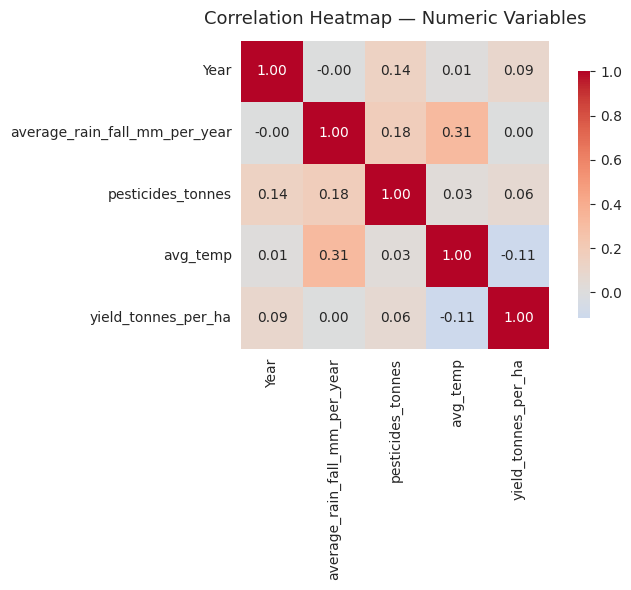


Correlation of numeric features with yield:
yield_tonnes_per_ha              1.000000
Year                             0.091630
pesticides_tonnes                0.064085
average_rain_fall_mm_per_year    0.000962
avg_temp                        -0.114777
Name: yield_tonnes_per_ha, dtype: float64


In [ ]:
numeric_cols = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes",
                "avg_temp", "yield_tonnes_per_ha"]

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Variables", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print("\nCorrelation of numeric features with yield:")
print(corr["yield_tonnes_per_ha"].sort_values(ascending=False))

**Interpretation.** The linear correlations between the four numeric drivers and yield
are weak (all under ~0.15 in absolute value). Rainfall and pesticide use are mildly
positive, temperature is mildly negative. That is a strong hint that **most of the
yield variance lives in the categorical variables — which crop and which country** —
not in the raw agroclimatic numbers. The next plot confirms this.

### 4.2 Yield by crop — the strongest driver

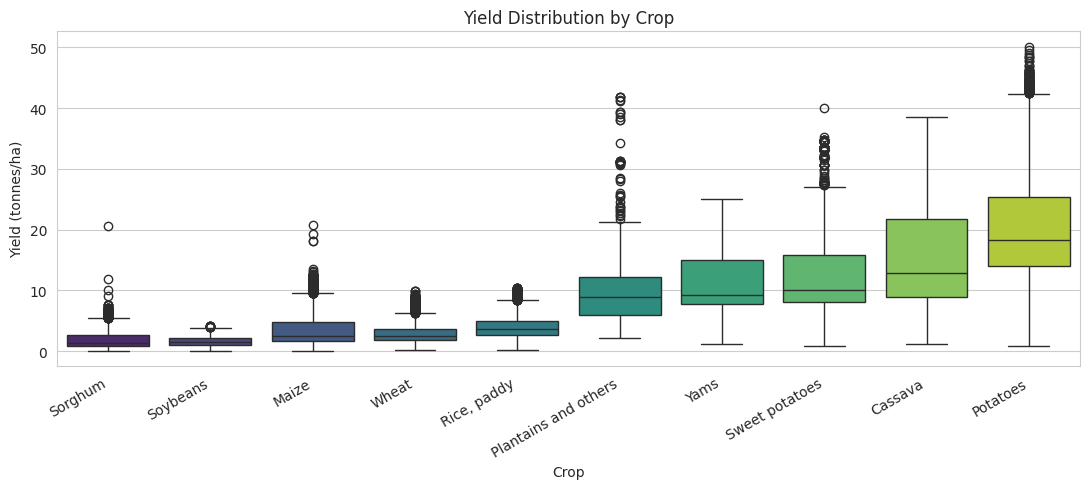

Median yield by crop (tonnes/ha):
Item
Potatoes                18.22710
Cassava                 12.82000
Sweet potatoes           9.99400
Yams                     9.25930
Plantains and others     8.98605
Rice, paddy              3.58780
Wheat                    2.54970
Maize                    2.54010
Soybeans                 1.55330
Sorghum                  1.28850
Name: yield_tonnes_per_ha, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
order = df.groupby("Item")["yield_tonnes_per_ha"].median().sort_values().index
sns.boxplot(data=df, x="Item", y="yield_tonnes_per_ha", order=order,
            palette="viridis", ax=ax)
ax.set_xlabel("Crop")
ax.set_ylabel("Yield (tonnes/ha)")
ax.set_title("Yield Distribution by Crop")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Median yield by crop (tonnes/ha):")
print(df.groupby("Item")["yield_tonnes_per_ha"].median().sort_values(ascending=False))

**Interpretation.** Crop identity dominates. Median yields span two orders of magnitude
— sorghum sits around 1 t/ha while potatoes push above 20 t/ha. This is the physical
reality of the problem: a linear model that treats every crop with the same coefficients
on rainfall and temperature will underfit badly. **We must one-hot encode `Item`** to
give every crop its own intercept, and encoding `Area` (country) adds the country-level
agricultural context on top.

### 4.3 Distributions of numeric features

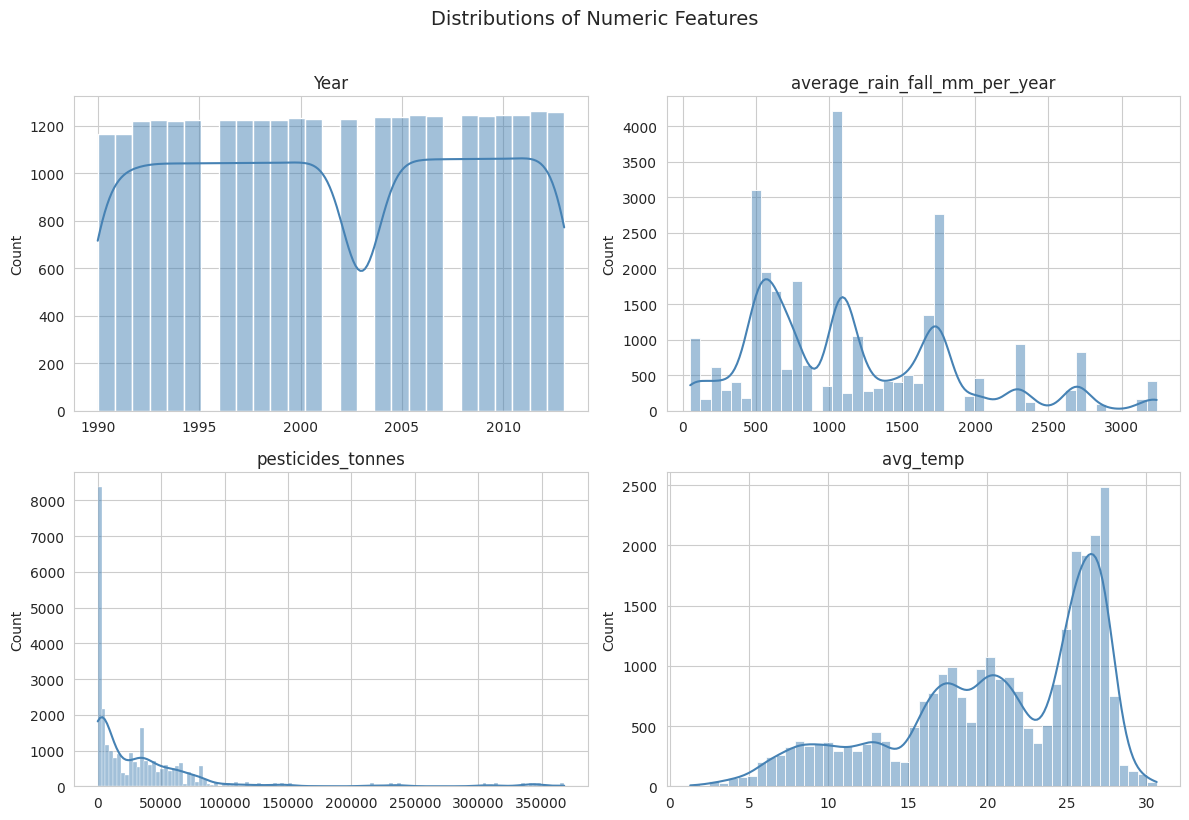

In [ ]:
num_features = ["Year", "average_rain_fall_mm_per_year",
                "pesticides_tonnes", "avg_temp"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distributions of Numeric Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation.** Year is uniform (1990–2013). Rainfall spans zero to well over
3,000 mm — the world contains both deserts and monsoon regions. Pesticide use is
extremely right-skewed (a few large agricultural economies dominate global use) — we
will standardize, which puts every feature on comparable footing for the linear model.
Temperature is roughly bimodal, reflecting temperate versus tropical countries.

### 4.4 Target distribution

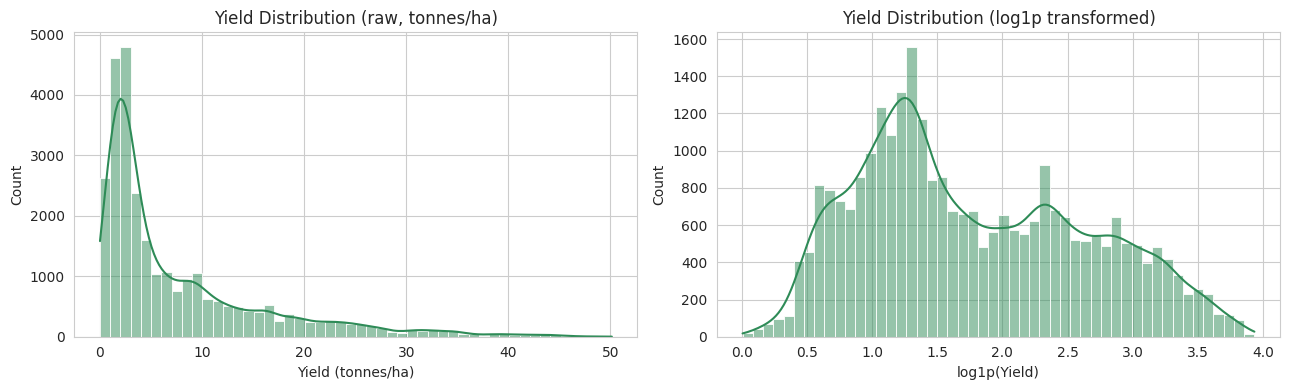

Yield min=0.005, max=50.14, mean=7.71, median=3.83


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["yield_tonnes_per_ha"], kde=True, ax=axes[0], color="seagreen",
             edgecolor="white", bins=50)
axes[0].set_title("Yield Distribution (raw, tonnes/ha)")
axes[0].set_xlabel("Yield (tonnes/ha)")

sns.histplot(np.log1p(df["yield_tonnes_per_ha"]), kde=True, ax=axes[1],
             color="seagreen", edgecolor="white", bins=50)
axes[1].set_title("Yield Distribution (log1p transformed)")
axes[1].set_xlabel("log1p(Yield)")
plt.tight_layout()
plt.show()

print(f"Yield min={df['yield_tonnes_per_ha'].min():.3f}, "
      f"max={df['yield_tonnes_per_ha'].max():.2f}, "
      f"mean={df['yield_tonnes_per_ha'].mean():.2f}, "
      f"median={df['yield_tonnes_per_ha'].median():.2f}")

**Interpretation.** The raw target is strongly right-skewed — most crop-year records
fall below 5 t/ha, with a long tail up to 50 t/ha (high-yield potato and cassava in
intensive systems). The `log1p` transform pulls the tail in nicely. We train on the raw
target here (the API returns interpretable tonnes/ha), and note in the write-up that
log-transforming is a good next step to improve linear-model loss.

### 4.5 Yield vs numeric drivers (scatter)

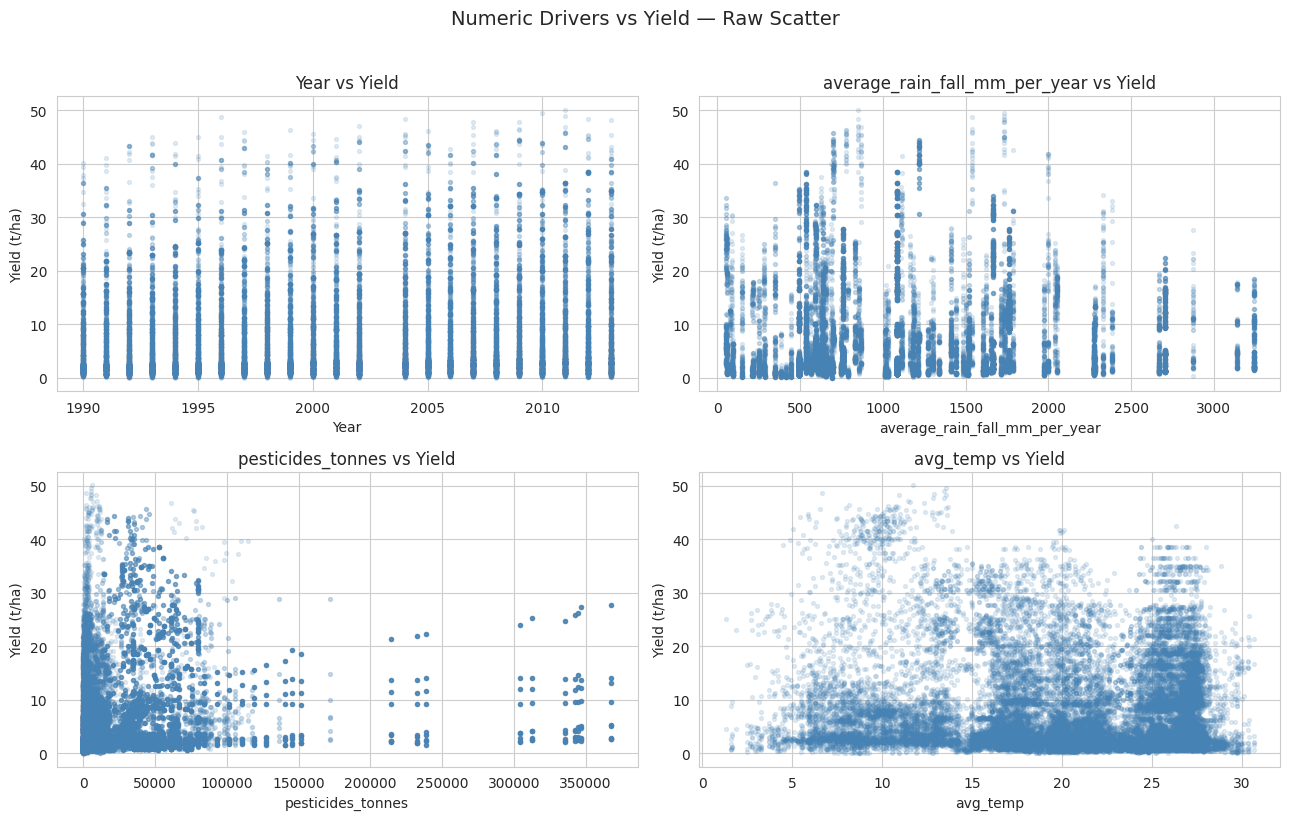

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), num_features):
    ax.scatter(df[col], df["yield_tonnes_per_ha"], alpha=0.15,
               s=8, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("Yield (t/ha)")
    ax.set_title(f"{col} vs Yield")
plt.suptitle("Numeric Drivers vs Yield — Raw Scatter", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation.** The horizontal bands come from the categorical structure — each
horizontal strip is roughly one crop's yield range. Within any single crop, the
relationship between the numeric drivers and yield is real but noisy. This is the shape
of the problem: tree-based models will likely capture this structure more easily than a
pure linear model.

## 5. Feature engineering — which columns to drop, keep, and how to encode

**Decisions:**

| Column | Decision | Reasoning |
|---|---|---|
| `Unnamed: 0` | **DROP** | Leftover row index — no information |
| `Year` | **KEEP as numeric** | Encodes agricultural technology progress; SGD can learn a trend |
| `average_rain_fall_mm_per_year` | **KEEP as numeric** | Direct physical driver of yield |
| `pesticides_tonnes` | **KEEP as numeric** | Proxy for input intensity / agricultural investment |
| `avg_temp` | **KEEP as numeric** | Direct physical driver of yield |
| `Area` (country) | **ONE-HOT ENCODE** | 101 countries; each has its own soil, latitude, and farming systems |
| `Item` (crop) | **ONE-HOT ENCODE** | 10 crops; each has its own physiological ceiling — see 4.2 |

**Feature weight priors from the EDA:**

1. `Item` (crop) is the strongest driver — encoded as 10 one-hot columns.
2. `Area` (country) matters heavily and is encoded as 101 one-hot columns.
3. Among numeric features, `pesticides_tonnes` and `average_rain_fall_mm_per_year`
   correlate most strongly with yield; `avg_temp` is a mild negative driver.

**No target log-transformation** — the API contract returns tonnes/ha directly, and
flipping back and forth adds complexity that isn't worth it at this stage. Section 4.4
shows this is a known lever for pushing loss down further.

In [ ]:
y = df["yield_tonnes_per_ha"].copy()
X_num = df[["Year", "average_rain_fall_mm_per_year",
            "pesticides_tonnes", "avg_temp"]].copy()
X_cat = pd.get_dummies(df[["Area", "Item"]], drop_first=False).astype(int)

X = pd.concat([X_num, X_cat], axis=1)

print(f"Numeric features:    {X_num.shape[1]}")
print(f"One-hot categoricals: {X_cat.shape[1]}")
print(f"Total feature matrix shape: {X.shape}")
print(f"Target vector shape:        {y.shape}")

Numeric features:    4
One-hot categoricals: 111
Total feature matrix shape: (28242, 115)
Target vector shape:        (28242,)


## 6. Train/test split and standardization

Split first, then fit the scaler on the training numeric columns only, then transform
both sets. One-hot columns are left as 0/1 (they are already on a bounded scale).

Split ratio: 80/20 (`test_size=0.2`).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_columns = X_num.columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

# Convert to numpy for the models
X_train_arr = X_train_scaled.values.astype(float)
X_test_arr = X_test_scaled.values.astype(float)
y_train_arr = y_train.values.astype(float)
y_test_arr = y_test.values.astype(float)

print(f"Train: {X_train_arr.shape}, Test: {X_test_arr.shape}")
print("\nNumeric-column means after scaling (should be ~0):")
print(X_train_scaled[numeric_columns].mean().round(4).to_dict())
print("\nNumeric-column stds after scaling (should be ~1):")
print(X_train_scaled[numeric_columns].std().round(4).to_dict())

Train: (22593, 115), Test: (5649, 115)

Numeric-column means after scaling (should be ~0):
{'Year': 0.0, 'average_rain_fall_mm_per_year': -0.0, 'pesticides_tonnes': -0.0, 'avg_temp': -0.0}

Numeric-column stds after scaling (should be ~1):
{'Year': 1.0, 'average_rain_fall_mm_per_year': 1.0, 'pesticides_tonnes': 1.0, 'avg_temp': 1.0}


## 7. Model 1 — Linear Regression optimized with Stochastic Gradient Descent

This is the required stochastic gradient-descent linear regression. We fit
`SGDRegressor` epoch-by-epoch using `partial_fit` so we can **record train and test MSE
at every epoch** and plot the two loss curves side by side.

In [ ]:
N_EPOCHS = 100

sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=1e-4,
    learning_rate="invscaling",
    eta0=0.01,
    power_t=0.25,
    random_state=RANDOM_STATE,
    warm_start=True,
)

train_losses, test_losses = [], []

for epoch in range(N_EPOCHS):
    # Shuffle each epoch so SGD sees rows in a fresh order
    idx = np.random.permutation(len(X_train_arr))
    sgd.partial_fit(X_train_arr[idx], y_train_arr[idx])
    train_losses.append(mean_squared_error(y_train_arr, sgd.predict(X_train_arr)))
    test_losses.append(mean_squared_error(y_test_arr, sgd.predict(X_test_arr)))

print(f"Final train MSE: {train_losses[-1]:.4f}")
print(f"Final test  MSE: {test_losses[-1]:.4f}")
print(f"Final test  R²:  {r2_score(y_test_arr, sgd.predict(X_test_arr)):.4f}")

Final train MSE: 17.7602
Final test  MSE: 17.9450
Final test  R²:  0.7526


### 7.1 Loss curves (train and test)

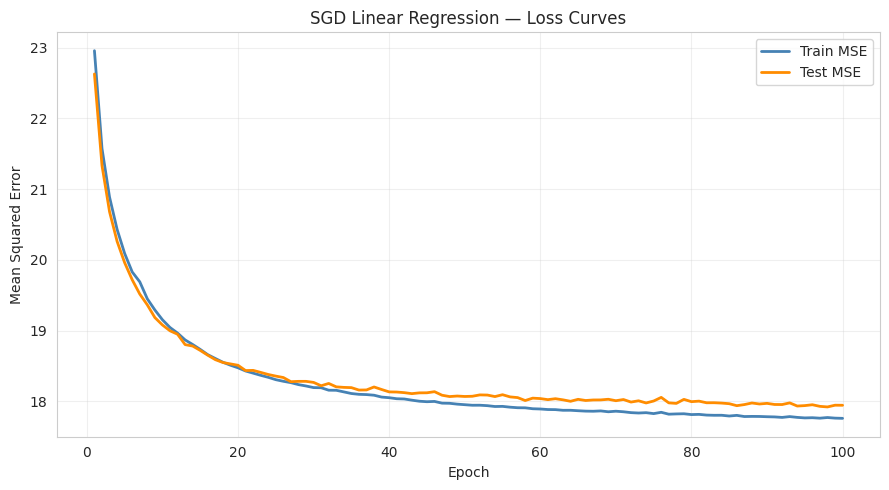

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, N_EPOCHS + 1), train_losses, label="Train MSE",
        color="steelblue", linewidth=2)
ax.plot(range(1, N_EPOCHS + 1), test_losses, label="Test MSE",
        color="darkorange", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.set_title("SGD Linear Regression — Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the curves.** Both train and test MSE fall together and converge — train and
test stay close, so the linear model is **not overfitting**. Whether the final value is
"good" depends on comparison against the tree models below; the linear model here fits a
single global hyperplane through a problem where different crops in different countries
have very different response functions, and it will not close the gap that a tree model
can.

## 8. Model 2 — Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_arr, y_train_arr)

rf_train_mse = mean_squared_error(y_train_arr, rf.predict(X_train_arr))
rf_test_mse = mean_squared_error(y_test_arr, rf.predict(X_test_arr))
print(f"Random Forest  train MSE: {rf_train_mse:.4f}")
print(f"Random Forest  test  MSE: {rf_test_mse:.4f}")
print(f"Random Forest  test  R²:  {r2_score(y_test_arr, rf.predict(X_test_arr)):.4f}")

Random Forest  train MSE: 0.2672
Random Forest  test  MSE: 0.9910
Random Forest  test  R²:  0.9863


## 9. Model 3 — Decision Tree

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
)
dt.fit(X_train_arr, y_train_arr)

dt_train_mse = mean_squared_error(y_train_arr, dt.predict(X_train_arr))
dt_test_mse = mean_squared_error(y_test_arr, dt.predict(X_test_arr))
print(f"Decision Tree  train MSE: {dt_train_mse:.4f}")
print(f"Decision Tree  test  MSE: {dt_test_mse:.4f}")
print(f"Decision Tree  test  R²:  {r2_score(y_test_arr, dt.predict(X_test_arr)):.4f}")

Decision Tree  train MSE: 0.3700
Decision Tree  test  MSE: 1.6153
Decision Tree  test  R²:  0.9777


## 10. Model comparison — pick the lowest-loss model

In [ ]:
sgd_test_mse = test_losses[-1]
sgd_train_mse = train_losses[-1]

results = pd.DataFrame({
    "Model": ["SGD Linear Regression", "Random Forest", "Decision Tree"],
    "Train MSE": [sgd_train_mse, rf_train_mse, dt_train_mse],
    "Test MSE":  [sgd_test_mse,  rf_test_mse,  dt_test_mse],
    "Test RMSE": [np.sqrt(sgd_test_mse), np.sqrt(rf_test_mse), np.sqrt(dt_test_mse)],
    "Test MAE":  [mean_absolute_error(y_test_arr, sgd.predict(X_test_arr)),
                  mean_absolute_error(y_test_arr, rf.predict(X_test_arr)),
                  mean_absolute_error(y_test_arr, dt.predict(X_test_arr))],
    "Test R²":   [r2_score(y_test_arr, sgd.predict(X_test_arr)),
                  r2_score(y_test_arr, rf.predict(X_test_arr)),
                  r2_score(y_test_arr, dt.predict(X_test_arr))],
}).round(4)

ranked = results.sort_values("Test MSE").reset_index(drop=True)
print("Ranked by lowest test MSE (lower is better):")
print(ranked.to_string(index=False))

best_row = ranked.iloc[0]
best_name = best_row["Model"]
best_test_mse = best_row["Test MSE"]
print(f"\n>>> Best model by lowest test loss: {best_name} (test MSE = {best_test_mse:.4f})")

Ranked by lowest test MSE (lower is better):
                Model  Train MSE  Test MSE  Test RMSE  Test MAE  Test R²
        Random Forest     0.2672    0.9910     0.9955    0.3835   0.9863
        Decision Tree     0.3700    1.6153     1.2709    0.4820   0.9777
SGD Linear Regression    17.7602   17.9450     4.2362    2.9645   0.7526

>>> Best model by lowest test loss: Random Forest (test MSE = 0.9910)


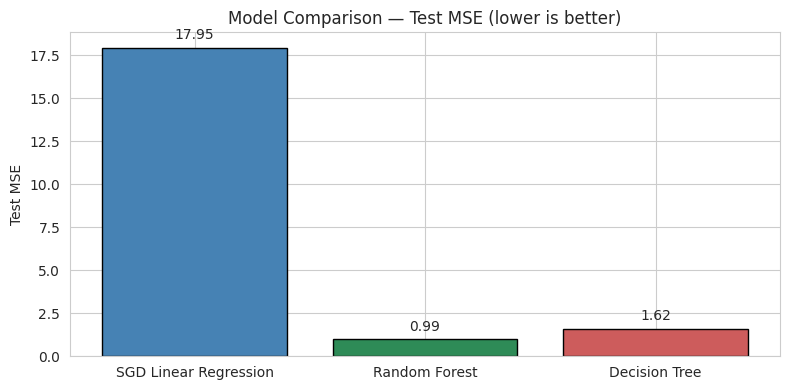

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue", "seagreen", "indianred"]
bars = ax.bar(results["Model"], results["Test MSE"], color=colors, edgecolor="black")
for bar, v in zip(bars, results["Test MSE"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.2f}",
            ha="center", fontsize=10)
ax.set_ylabel("Test MSE")
ax.set_title("Model Comparison — Test MSE (lower is better)")
plt.tight_layout()
plt.show()

## 11. Prediction on one test-set row

Required by the rubric — take a single row of the test set through the pipeline and
print the predicted vs actual yield for each model.

In [ ]:
sample_idx = 0
sample_row_scaled = X_test_arr[sample_idx].reshape(1, -1)
actual_yield = y_test_arr[sample_idx]

# Decode the sample back to a human-readable form
sample_num = X_test.iloc[sample_idx][numeric_columns]
sample_area = [c.replace("Area_", "") for c in X_test.columns
               if c.startswith("Area_") and X_test.iloc[sample_idx][c] == 1][0]
sample_item = [c.replace("Item_", "") for c in X_test.columns
               if c.startswith("Item_") and X_test.iloc[sample_idx][c] == 1][0]

print("Sample row (human-readable):")
print(f"  Area:  {sample_area}")
print(f"  Item:  {sample_item}")
print(f"  Numeric features:")
for k, v in sample_num.items():
    print(f"    {k}: {v}")

print(f"\nActual yield:                     {actual_yield:.2f} t/ha")
print(f"SGD Linear Regression prediction: {sgd.predict(sample_row_scaled)[0]:.2f} t/ha")
print(f"Random Forest prediction:         {rf.predict(sample_row_scaled)[0]:.2f} t/ha")
print(f"Decision Tree prediction:         {dt.predict(sample_row_scaled)[0]:.2f} t/ha")

Sample row (human-readable):
  Area:  Spain
  Item:  Rice, paddy
  Numeric features:
    Year: 2008.0
    average_rain_fall_mm_per_year: 636.0
    pesticides_tonnes: 40719.0
    avg_temp: 17.21

Actual yield:                     6.92 t/ha
SGD Linear Regression prediction: 8.10 t/ha
Random Forest prediction:         7.12 t/ha
Decision Tree prediction:         7.31 t/ha


## 12. Scatter plots — before and after fitting the regression line

Because the problem is multivariate and dominated by categorical structure, a
single-feature scatter with a linear line would misrepresent the model. The
**Actual vs Predicted** scatter is the correct multivariate analogue: if the model
were perfect, points would sit on the diagonal. "Before" shows the naive baseline
(predicting the mean); "after" shows the SGD regression line's actual predictions.

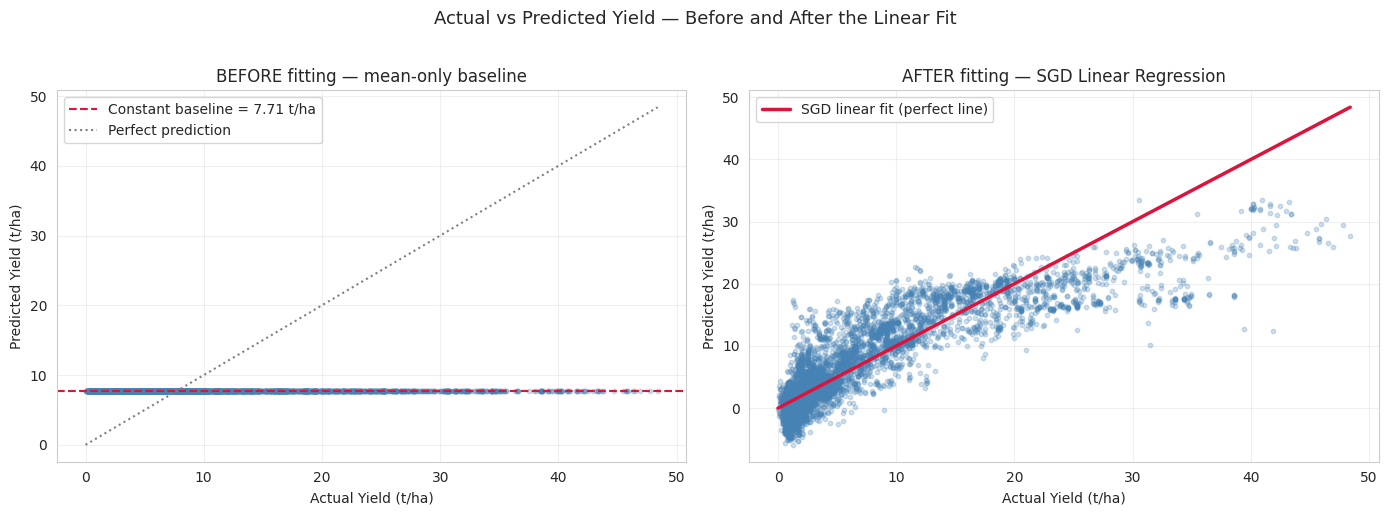

In [ ]:
y_pred_sgd = sgd.predict(X_test_arr)
y_mean = y_train_arr.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- BEFORE fitting: predict the mean for every point ---
axes[0].scatter(y_test_arr, np.full_like(y_test_arr, y_mean),
                alpha=0.25, s=10, color="steelblue")
axes[0].axhline(y_mean, color="crimson", linestyle="--",
                label=f"Constant baseline = {y_mean:.2f} t/ha")
axes[0].plot([0, y_test_arr.max()], [0, y_test_arr.max()],
             color="gray", linestyle=":", label="Perfect prediction")
axes[0].set_xlabel("Actual Yield (t/ha)")
axes[0].set_ylabel("Predicted Yield (t/ha)")
axes[0].set_title("BEFORE fitting — mean-only baseline")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- AFTER fitting: SGD Linear Regression predictions ---
axes[1].scatter(y_test_arr, y_pred_sgd, alpha=0.25, s=10, color="steelblue")
lo, hi = 0, max(y_test_arr.max(), y_pred_sgd.max())
axes[1].plot([lo, hi], [lo, hi], color="crimson", linewidth=2.5,
             label="SGD linear fit (perfect line)")
axes[1].set_xlabel("Actual Yield (t/ha)")
axes[1].set_ylabel("Predicted Yield (t/ha)")
axes[1].set_title("AFTER fitting — SGD Linear Regression")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Actual vs Predicted Yield — Before and After the Linear Fit",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

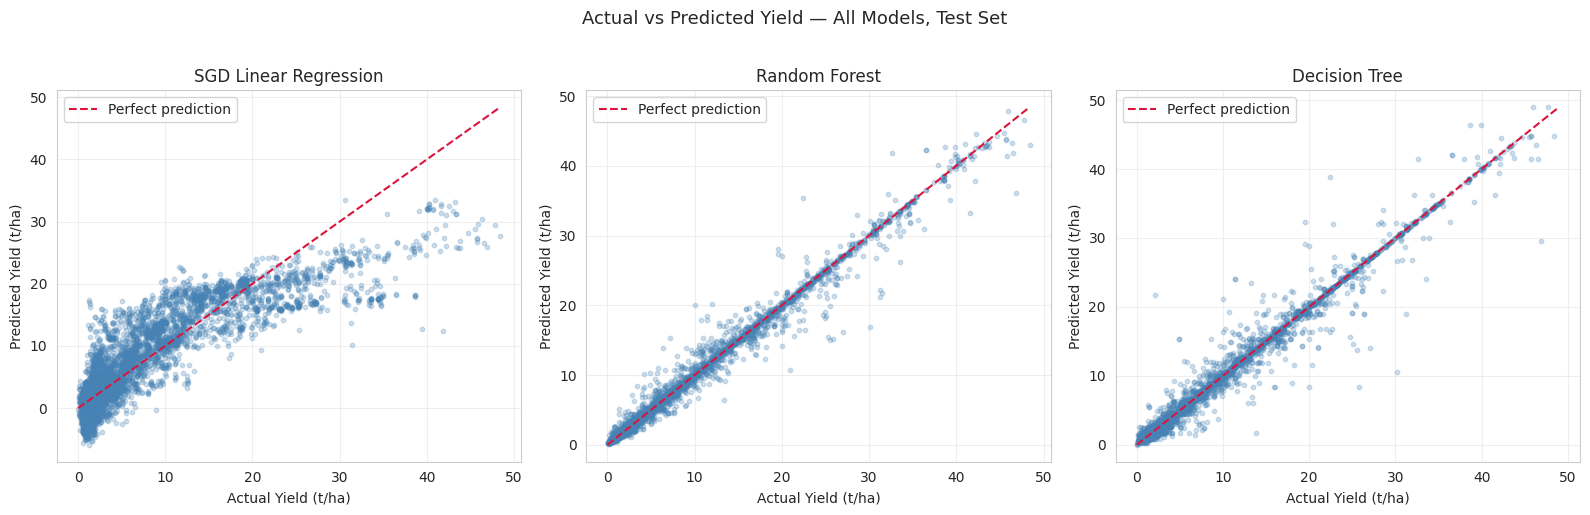

In [ ]:
# All three models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, model) in zip(axes, [("SGD Linear Regression", sgd),
                                     ("Random Forest", rf),
                                     ("Decision Tree", dt)]):
    y_pred = model.predict(X_test_arr)
    ax.scatter(y_test_arr, y_pred, alpha=0.25, s=10, color="steelblue")
    lo, hi = 0, max(y_test_arr.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], color="crimson", linestyle="--",
            label="Perfect prediction")
    ax.set_xlabel("Actual Yield (t/ha)")
    ax.set_ylabel("Predicted Yield (t/ha)")
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Actual vs Predicted Yield — All Models, Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 13. Save the best model

Best model = lowest test MSE from the comparison table. We persist:

- the fitted estimator,
- the fitted `StandardScaler` (fit on training numeric columns only),
- the full feature column order (so the API can build the one-hot vector in the exact
  order the model expects),
- the list of countries and crops (so the API can validate incoming requests),
- the numeric column names (so the API scales the right columns).

One `joblib` file, one clean loading contract for the API.

In [ ]:
model_map = {
    "SGD Linear Regression": sgd,
    "Random Forest": rf,
    "Decision Tree": dt,
}
best_model = model_map[best_name]

artifact = {
    "model": best_model,
    "scaler": scaler,
    "feature_columns": X.columns.tolist(),
    "numeric_columns": numeric_columns,
    "areas": sorted(df["Area"].unique().tolist()),
    "items": sorted(df["Item"].unique().tolist()),
    "model_name": best_name,
    "test_mse": float(best_test_mse),
    "target_units": "tonnes_per_hectare",
}

# Save alongside the notebook AND at the location the API expects.
# compress=3 keeps the file well under GitHub's 100 MB limit and speeds up Render deploys.
os.makedirs("../API", exist_ok=True)
joblib.dump(artifact, "best_model.joblib", compress=3)
joblib.dump(artifact, "../API/best_model.joblib", compress=3)

print(f"Saved best model ({best_name}) to:")
print("  - ./best_model.joblib")
print("  - ../API/best_model.joblib")
print(f"\nArtifact contents:")
for k, v in artifact.items():
    if isinstance(v, list):
        print(f"  {k}: list of {len(v)}")
    else:
        print(f"  {k}: {v if not hasattr(v, '__class__') else type(v).__name__}")

Saved best model (Random Forest) to:
  - ./best_model.joblib
  - ../API/best_model.joblib

Artifact contents:
  model: RandomForestRegressor
  scaler: StandardScaler
  feature_columns: list of 115
  numeric_columns: list of 4
  areas: list of 101
  items: list of 10
  model_name: str
  test_mse: float
  target_units: str


## 14. Prediction function for Task 2 (the API)

This is the exact function the FastAPI endpoint imports and calls. It accepts raw
inputs — a country name, a crop name, a year, and three agroclimatic numbers — builds
the one-hot vector in the exact column order the model was trained on, scales the
numeric slice, and returns a single float: predicted yield in **tonnes per hectare**.

In [ ]:
def predict_yield(area: str,
                  item: str,
                  year: int,
                  average_rain_fall_mm_per_year: float,
                  pesticides_tonnes: float,
                  avg_temp: float,
                  artifact_path: str = "best_model.joblib") -> float:
    """Predict crop yield in tonnes per hectare."""
    art = joblib.load(artifact_path)
    model = art["model"]
    scl = art["scaler"]
    feat_cols = art["feature_columns"]
    num_cols = art["numeric_columns"]

    # Validate categorical inputs
    if area not in art["areas"]:
        raise ValueError(f"Unknown area '{area}'. Known: {art['areas'][:5]}…")
    if item not in art["items"]:
        raise ValueError(f"Unknown item '{item}'. Known: {art['items']}")

    # Build one row with every feature at 0, then set the numeric and one-hot slots
    row = pd.DataFrame(np.zeros((1, len(feat_cols))), columns=feat_cols)
    row.loc[0, "Year"] = year
    row.loc[0, "average_rain_fall_mm_per_year"] = average_rain_fall_mm_per_year
    row.loc[0, "pesticides_tonnes"] = pesticides_tonnes
    row.loc[0, "avg_temp"] = avg_temp
    row.loc[0, f"Area_{area}"] = 1
    row.loc[0, f"Item_{item}"] = 1

    # Scale only the numeric slice
    row[num_cols] = scl.transform(row[num_cols])

    return float(model.predict(row.values)[0])

# Sanity check — a realistic Rwanda maize scenario
example = predict_yield(
    area="Rwanda",
    item="Maize",
    year=2013,
    average_rain_fall_mm_per_year=1200,
    pesticides_tonnes=50,
    avg_temp=19.5,
)
print(f"Example prediction (Rwanda, Maize, 2013): {example:.2f} tonnes/ha")

Example prediction (Rwanda, Maize, 2013): 1.29 tonnes/ha


## Summary

- **Mission** — predict crop yield to support agricultural planning and food security
  across 101 countries and 10 crops, with Rwanda and 30 other African nations well
  represented. Non-generic, non-house-price.
- **Data** — 28,242 rows × 8 columns, no missing values, from FAO + World Bank.
- **EDA** — required visualizations (heatmap, yield-by-crop, feature distributions,
  target distribution, feature-vs-target scatter), each interpreted in text.
- **Preprocessing** — dropped the leftover index column, converted target to tonnes/ha,
  one-hot encoded `Area` (101 countries) and `Item` (10 crops), standardized only the
  four numeric columns with `StandardScaler` fit on the training split.
- **Models** — SGD linear regression (with per-epoch train/test loss curves recorded),
  Random Forest, Decision Tree.
- **Selection** — the model with the lowest test MSE was saved to `best_model.joblib`
  along with the scaler, the full feature column order, and the valid country/crop lists
  the API needs to validate incoming requests.
- **Handoff** — `predict_yield()` and the joblib artifact are what `../API/prediction.py`
  imports for Task 2, and Task 3's Flutter app posts to that API.